# **India Air Quality &amp; Crop Yield — EDA Lab Data Preprocessing, Visualisation &amp; Exploration**

## *Task 1*

### IMPORTING FILES AND LIBRARIES:

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [54]:
aqi_df = pd.read_csv("city_day.csv")
crop_df = pd.read_csv("crop_production.csv")
aqi_df['Date'] = pd.to_datetime(aqi_df['Date'])
print("Files loaded.")
print(f"AQI shape   : {aqi_df.shape}")
print(f"Crop shape  : {crop_df.shape}")

Files loaded.
AQI shape   : (29531, 16)
Crop shape  : (246091, 7)


### ANALYZING AQI DATASET:

In [55]:
print("\nColumn Names:")
print(aqi_df.columns.tolist())

print("\nData Types:")
print(aqi_df.dtypes)


Column Names:
['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']

Data Types:
City                     str
Date          datetime64[us]
PM2.5                float64
PM10                 float64
NO                   float64
NO2                  float64
NOx                  float64
NH3                  float64
CO                   float64
SO2                  float64
O3                   float64
Benzene              float64
Toluene              float64
Xylene               float64
AQI                  float64
AQI_Bucket               str
dtype: object


#### FIRST LOOK AT DATA:

In [56]:
aqi_df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [57]:
aqi_df.sample(5)

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
13554,Gurugram,2019-01-24,114.82,194.17,20.80,23.48,31.22,NaN,2.31,6.31,28.39,0.00,0.00,NaN,294.0,Poor
16377,Hyderabad,2019-12-05,82.44,152.49,10.10,47.96,32.55,15.47,0.92,8.32,27.09,2.88,18.28,0.69,172.0,Moderate
23586,Mumbai,2019-09-28,8.32,27.38,18.67,10.20,28.84,16.88,0.28,7.82,7.38,2.92,NaN,NaN,40.0,Good
26385,Talcher,2018-12-08,94.41,239.24,52.82,NaN,37.14,13.25,2.58,21.66,6.64,NaN,NaN,NaN,241.0,Poor
8266,Chennai,2016-03-08,60.92,NaN,6.31,12.17,11.77,11.81,1.01,3.00,46.66,3.03,2.47,NaN,120.0,Moderate


#### CITY SUMMARY:

In [58]:
print("\nUnique Cities:")
print(aqi_df['City'].nunique())


Unique Cities:
26


In [59]:
print("\nCities Present:")
print(aqi_df['City'].unique())


Cities Present:
<StringArray>
[         'Ahmedabad',             'Aizawl',          'Amaravati',
           'Amritsar',          'Bengaluru',             'Bhopal',
       'Brajrajnagar',         'Chandigarh',            'Chennai',
         'Coimbatore',              'Delhi',          'Ernakulam',
           'Gurugram',           'Guwahati',          'Hyderabad',
             'Jaipur',         'Jorapokhar',              'Kochi',
            'Kolkata',            'Lucknow',             'Mumbai',
              'Patna',           'Shillong',            'Talcher',
 'Thiruvananthapuram',      'Visakhapatnam']
Length: 26, dtype: str


#### MISSING VALUES ANALYSIS:

In [60]:
missing = pd.DataFrame({
    'Missing Values': aqi_df.isnull().sum(),
    'Percentage': (aqi_df.isnull().sum()/len(aqi_df))*100
})

missing = missing.sort_values('Percentage', ascending=False)

missing

,Missing Values,Percentage
Xylene,18109,61.322001
PM10,11140,37.723071
NH3,10328,34.973418
Toluene,8041,27.229014
Benzene,5623,19.041008
AQI,4681,15.851139
AQI_Bucket,4681,15.851139
PM2.5,4598,15.570079
NOx,4185,14.171549
O3,4022,13.619586


Xylene has a very high percentage of missing values

#### DUPLICATE RECORDS:

In [61]:
duplicates = aqi_df.duplicated().sum()
print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


No duplicate rows

#### DATE ANALYSIS:

In [62]:
aqi_df['Date'] = pd.to_datetime(aqi_df['Date'])

print("Earliest Date :", aqi_df['Date'].min())
print("Latest Date   :", aqi_df['Date'].max())

print("Number of Unique Dates :", aqi_df['Date'].nunique())

Earliest Date : 2015-01-01 00:00:00
Latest Date   : 2020-07-01 00:00:00
Number of Unique Dates : 2009


The dataset has records spanning over 5 years

#### NUMERICAL STATISTICS

In [63]:
aqi_df.describe()

,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,29531,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000
mean,2018-05-14 05:40:15.807118,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
min,2015-01-01 00:00:00,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,2017-04-16 00:00:00,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000
50%,2018-08-05 00:00:00,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000
75%,2019-09-03 00:00:00,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000
max,2020-07-01 00:00:00,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000
std,NaN,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585


#### AQI STATISTICS:

In [64]:
print("AQI Statistics")

print("Minimum AQI :", aqi_df['AQI'].min())
print("Maximum AQI :", aqi_df['AQI'].max())
print("Average AQI :", aqi_df['AQI'].mean())
print("Median AQI  :", aqi_df['AQI'].median())

AQI Statistics
Minimum AQI : 13.0
Maximum AQI : 2049.0
Average AQI : 166.4635814889336
Median AQI  : 118.0


#### OUTLIER CHECK:

In [65]:
numeric_cols = aqi_df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    Q1 = aqi_df[col].quantile(0.25)
    Q3 = aqi_df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((aqi_df[col] < lower) | (aqi_df[col] > upper)).sum()

    print(f"{col}: {outliers} outliers")

PM2.5: 1982 outliers
PM10: 1057 outliers
NO: 2459 outliers
NO2: 1188 outliers
NOx: 1868 outliers
NH3: 1015 outliers
CO: 2475 outliers
SO2: 2578 outliers
O3: 713 outliers
Benzene: 1668 outliers
Toluene: 2427 outliers
Xylene: 1119 outliers
AQI: 1358 outliers


#### CITYWISE RECORD COUNT:

In [66]:
city_count = aqi_df['City'].value_counts()

city_count

City
Ahmedabad             2009
Bengaluru             2009
Chennai               2009
Delhi                 2009
Lucknow               2009
Mumbai                2009
Hyderabad             2006
Patna                 1858
Gurugram              1679
Visakhapatnam         1462
Amritsar              1221
Jorapokhar            1169
Jaipur                1114
Thiruvananthapuram    1112
Amaravati              951
Brajrajnagar           938
Talcher                925
Kolkata                814
Guwahati               502
Coimbatore             386
Shillong               310
Chandigarh             304
Bhopal                 289
Ernakulam              162
Kochi                  162
Aizawl                 113
Name: count, dtype: int64

#### STRUCTURED DATA PROFILE:

In [67]:
profile = pd.DataFrame({
    'Data Type': aqi_df.dtypes,
    'Missing Values': aqi_df.isnull().sum(),
    'Unique Values': aqi_df.nunique()
})

profile

,Data Type,Missing Values,Unique Values
City,str,0,26
Date,datetime64[us],0,2009
PM2.5,float64,4598,11716
PM10,float64,11140,12571
NO,float64,3582,5776
NO2,float64,3585,7404
NOx,float64,4185,8156
NH3,float64,10328,5922
CO,float64,2059,1779
SO2,float64,3854,4761


- Number of Rows: 29,531
- Number of Columns: 16
- Cities Covered: 26 Indian Cities
- Time Period: 2015 to 2020

#### Missing Values
Several columns contain substantial missing data:
- Xylene has over 60% missing values.
- PM10 has over 35% missing values.
- NH3 has over 30% missing values.
- AQI and AQI_Bucket contain missing records.

#### Duplicate Records
No duplicate rows were detected.

#### Data Types
Most pollutant columns are numerical.
Date should be converted to datetime format before analysis.

#### Outliers
Air quality measurements contain extreme values that may represent pollution spikes or measurement errors.

### Observation / Concern

The most significant concern is the large amount of missing data in important pollutant variables such as Xylene, PM10, and NH3. Before building predictive models, a data scientist should investigate whether these missing values are random or concentrated in specific cities or time periods. 

### ANALYZING CROP DATASET:

In [68]:
print("\nColumn Names:")
print(crop_df.columns.tolist())

print("\nData Types:")
print(crop_df.dtypes)


Column Names:
['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'Area', 'Production']

Data Types:
State_Name           str
District_Name        str
Crop_Year          int64
Season               str
Crop                 str
Area             float64
Production       float64
dtype: object


#### FIRST LOOK:

In [69]:
crop_df.head()

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0


In [70]:
crop_df.sample(5)

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
86819,Karnataka,DHARWAD,2006,Kharif,Gram,900.0,267.0
141269,Meghalaya,WEST GARO HILLS,2004,Kharif,Maize,4325.0,6568.0
17476,Assam,DIMA HASAO,2009,Autumn,Rice,6441.0,8947.0
221885,Uttar Pradesh,MATHURA,2006,Kharif,Arhar/Tur,3372.0,2857.0
140551,Meghalaya,RI BHOI,2014,Whole Year,Maize,1585.0,5010.0


#### DATASET OVERVIEW:

In [71]:
print("\nNumber of States:", crop_df['State_Name'].nunique())
print("Number of Districts:", crop_df['District_Name'].nunique())
print("Number of Crops:", crop_df['Crop'].nunique())


Number of States: 33
Number of Districts: 646
Number of Crops: 124


In [72]:
print("\nCrop Year Range:")
print("Earliest Year:", crop_df['Crop_Year'].min())
print("Latest Year:", crop_df['Crop_Year'].max())


Crop Year Range:
Earliest Year: 1997
Latest Year: 2015


#### MISSING VALUES:

In [73]:
missing = pd.DataFrame({
    'Missing Values': crop_df.isnull().sum(),
    'Percentage': round((crop_df.isnull().sum()/len(crop_df))*100,2)
})

missing.sort_values('Percentage', ascending=False)

,Missing Values,Percentage
Production,3730,1.52
State_Name,0,0.00
District_Name,0,0.00
Crop_Year,0,0.00
Season,0,0.00
Crop,0,0.00
Area,0,0.00


#### DUPLICATE RECORDS

In [74]:
duplicates = crop_df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


#### NUMERICAL STATISTICS:

In [75]:
crop_df.describe()

,Crop_Year,Area,Production
count,246091.000000,2.460910e+05,2.423610e+05
mean,2005.643018,1.200282e+04,5.825034e+05
std,4.952164,5.052340e+04,1.706581e+07
min,1997.000000,4.000000e-02,0.000000e+00
25%,2002.000000,8.000000e+01,8.800000e+01
50%,2006.000000,5.820000e+02,7.290000e+02
75%,2010.000000,4.392000e+03,7.023000e+03
max,2015.000000,8.580100e+06,1.250800e+09


#### UNIQUE VALUES:

In [76]:
for col in crop_df.columns:
    print(f"{col}: {crop_df[col].nunique()} unique values")

State_Name: 33 unique values
District_Name: 646 unique values
Crop_Year: 19 unique values
Season: 6 unique values
Crop: 124 unique values
Area: 38442 unique values
Production: 51627 unique values


#### TOP STATES:

In [77]:
crop_df['State_Name'].value_counts().head(10)

State_Name
Uttar Pradesh     33306
Madhya Pradesh    22943
Karnataka         21122
Bihar             18885
Assam             14628
Odisha            13575
Tamil Nadu        13547
Maharashtra       12628
Rajasthan         12514
Chhattisgarh      10709
Name: count, dtype: int64

#### TOP CROPS:

In [78]:
crop_df['Crop'].value_counts().head(10)

Crop
Rice                 15104
Maize                13947
Moong(Green Gram)    10318
Urad                  9850
Sesamum               9046
Groundnut             8834
Sugarcane             7921
Wheat                 7899
Rapeseed &Mustard     7592
Arhar/Tur             7578
Name: count, dtype: int64

#### SEASON DISTRIBUTION:

In [79]:
crop_df['Season'].value_counts()

Season
Kharif         95951
Rabi           66987
Whole Year     57305
Summer         14841
Winter          6058
Autumn          4949
Name: count, dtype: int64

#### OUTLIERS:

In [80]:
numeric_cols = ['Area', 'Production']

for col in numeric_cols:
    Q1 = crop_df[col].quantile(0.25)
    Q3 = crop_df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((crop_df[col] < lower) | (crop_df[col] > upper)).sum()

    print(f"{col}: {outliers} outliers")

Area: 40705 outliers
Production: 42390 outliers


#### DATA PROFILES

In [81]:
profile = pd.DataFrame({
    'Data Type': crop_df.dtypes,
    'Missing Values': crop_df.isnull().sum(),
    'Unique Values': crop_df.nunique()
})

profile

,Data Type,Missing Values,Unique Values
State_Name,str,0,33
District_Name,str,0,646
Crop_Year,int64,0,19
Season,str,0,6
Crop,str,0,124
Area,float64,0,38442
Production,float64,3730,51627


- Number of Rows: 246,091
- Number of Columns: 7
- Contains crop production information across Indian states and districts.

#### Missing Values
- Production contains missing values.

#### Outliers
- Area and Production contain extremely large values.
- These may represent major agricultural regions or data-entry errors.

#### Coverage
- Multiple states and districts are represented.
- Many crop types are included.
- Data spans several crop years and seasons.

### Observation / Concern

The primary concern is the presence of missing values in the Production column, which is the target variable for many agricultural analyses. Additionally, Area and Production are likely to contain significant outliers because agricultural output varies greatly across regions and crops. These values should be investigated before modeling or statistical analysis to ensure they are valid and not data-entry mistakes.

## *Task 2*

After inspecting the air quality dataset, several columns were found to contain missing values. A single strategy (dropping all rows or filling all values with the mean) would result in either significant data loss or inaccurate data. Therefore, a column-specific approach was adopted.


#### PM2.5
- Missing Values: Moderate
- Strategy: Median Imputation
- Reason: PM2.5 measurements are often skewed due to pollution spikes. Median is less affected by extreme values than mean.

#### PM10
- Missing Values: High (~38%)
- Strategy: Median Imputation
- Reason: PM10 is an important pollutant variable. Dropping the column would remove useful information, while median imputation preserves the column.

#### NO
- Missing Values: Low
- Strategy: Median Imputation
- Reason: Numerical pollutant data may contain outliers; median is robust.

#### NO2
- Missing Values: Moderate
- Strategy: Median Imputation
- Reason: Important air-quality feature that should be retained.

#### NOx
- Missing Values: Moderate
- Strategy: Median Imputation
- Reason: Closely related to NO and NO2 and valuable for analysis.

#### NH3
- Missing Values: High (~35%)
- Strategy: Median Imputation
- Reason: Although many values are missing, NH3 remains an important pollutant indicator.

#### CO
- Missing Values: Moderate
- Strategy: Median Imputation
- Reason: Continuous numerical variable with possible extreme values.

#### SO2
- Missing Values: Moderate
- Strategy: Median Imputation
- Reason: Important pollutant feature.

#### O3
- Missing Values: Moderate
- Strategy: Median Imputation
- Reason: Retain ozone information while avoiding loss of rows.

#### Benzene
- Missing Values: High (~19%)
- Strategy: Median Imputation
- Reason: Numerical feature with skewed distribution.

#### Toluene
- Missing Values: High (~27%)
- Strategy: Median Imputation
- Reason: Retain useful information without introducing bias from mean values.

#### Xylene
- Missing Values: Very High (~61%)
- Strategy: Drop Column
- Reason: More than half the values are missing. Imputation would create mostly artificial data and reduce reliability.

#### AQI
- Missing Values: Moderate (~16%)
- Strategy: Drop Rows
- Reason: Imputing a target fabricates ground truth, which would corrupt any downstream model.

#### AQI_Bucket
- Missing Values: Same rows as AQI
- Strategy: Drop Rows.
- Reason: Same as above.

In [82]:
df_clean = aqi_df.copy()

df_clean.drop(columns=['Xylene'], inplace=True)

median_cols = [
    'PM2.5', 'PM10', 'NO', 'NO2', 'NOx',
    'NH3', 'CO', 'SO2', 'O3',
    'Benzene', 'Toluene'
]

for col in median_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

df_clean = df_clean.dropna(subset=['AQI'])

In [83]:
before = aqi_df.isnull().sum()

after = df_clean.isnull().sum()

comparison = pd.DataFrame({
    "Before": before,
    "After": after
})

comparison

,Before,After
AQI,4681,0.0
AQI_Bucket,4681,0.0
Benzene,5623,0.0
CO,2059,0.0
City,0,0.0
Date,0,0.0
NH3,10328,0.0
NO,3582,0.0
NO2,3585,0.0
NOx,4185,0.0


On inspection, only ONE column has missing values : Production (1.52%, ~3730 rows).
All other columns (State_Name, District_Name, Crop_Year, Season, Crop, Area) are complete.

In [84]:
rows_before = len(crop_df)
crop_df.dropna(subset=['Production'], inplace=True)

In [85]:
print(f"\nTotal rows before : {rows_before}")
print(f"Total rows after  : {len(crop_df)}")
print(f"Rows dropped      : {rows_before - len(crop_df)} ({(rows_before - len(crop_df))/rows_before*100:.2f}% of data)")


Total rows before : 246091
Total rows after  : 242361
Rows dropped      : 3730 (1.52% of data)


## *Task 3*

In [88]:
crop_before = len(crop_df)
aqi_before  = len(aqi_df)

print("=== BEFORE ===")
print(f"Crop rows : {crop_before} | Duplicates: {crop_df.duplicated().sum()}")
print(f"AQI rows  : {aqi_before}  | Duplicates: {aqi_df.duplicated().sum()}")

print("\nCrop State_Name variants with repr() to expose hidden characters:")
for s in sorted(crop_df['State_Name'].unique()):
    if s != s.strip():
        print(f"  ISSUE → {repr(s)}")
    else:
        print(f"  OK    → {repr(s)}")

print("\nCrop Season variants:")
for s in crop_df['Season'].unique():
    print(f"  {repr(s)}")

crop_df['State_Name'] = crop_df['State_Name'].str.strip().str.title()

crop_df['Season'] = crop_df['Season'].str.strip()

city_to_state = {
    'Ahmedabad'         : 'Gujarat',
    'Aizawl'            : 'Mizoram',
    'Amaravati'         : 'Andhra Pradesh',
    'Amritsar'          : 'Punjab',
    'Bengaluru'         : 'Karnataka',
    'Bhopal'            : 'Madhya Pradesh',
    'Brajrajnagar'      : 'Odisha',
    'Chandigarh'        : 'Chandigarh',
    'Chennai'           : 'Tamil Nadu',
    'Coimbatore'        : 'Tamil Nadu',
    'Delhi'             : 'Delhi',
    'Ernakulam'         : 'Kerala',
    'Gurugram'          : 'Haryana',
    'Guwahati'          : 'Assam',
    'Hyderabad'         : 'Telangana',
    'Jaipur'            : 'Rajasthan',
    'Jorapokhar'        : 'Jharkhand',
    'Kochi'             : 'Kerala',
    'Kolkata'           : 'West Bengal',
    'Lucknow'           : 'Uttar Pradesh',
    'Mumbai'            : 'Maharashtra',
    'Patna'             : 'Bihar',
    'Shillong'          : 'Meghalaya',
    'Talcher'           : 'Odisha',
    'Thiruvananthapuram': 'Kerala',
    'Visakhapatnam'     : 'Andhra Pradesh'
}

aqi_df['State'] = aqi_df['City'].map(city_to_state)
print(f"\nUnmapped AQI cities: {aqi_df[aqi_df['State'].isna()]['City'].unique()}")

aqi_df['State'] = aqi_df['State'].str.strip().str.title()

crop_df.drop_duplicates(inplace=True)
aqi_df.drop_duplicates(inplace=True)

print("\n=== AFTER ===")
print(f"Crop rows : {len(crop_df)} | Duplicates removed: {crop_before - len(crop_df)}")
print(f"AQI rows  : {len(aqi_df)}  | Duplicates removed: {aqi_before - len(aqi_df)}")

print("\nCrop State_Name after cleaning (check for trailing spaces):")
for s in sorted(crop_df['State_Name'].unique()):
    print(f"  {repr(s)}")

print("\nCrop Season after cleaning:")
print(crop_df['Season'].unique())

aqi_states  = set(aqi_df['State'].dropna().unique())
crop_states = set(crop_df['State_Name'].unique())
matched     = aqi_states & crop_states
unmatched   = aqi_states - crop_states

print(f"\nAQI states that MATCH crop states  : {len(matched)} → {sorted(matched)}")
print(f"AQI states with NO match in crop   : {sorted(unmatched)}")

=== BEFORE ===
Crop rows : 242361 | Duplicates: 0
AQI rows  : 29531  | Duplicates: 0

Crop State_Name variants with repr() to expose hidden characters:
  OK    → 'Andaman And Nicobar Islands'
  OK    → 'Andhra Pradesh'
  OK    → 'Arunachal Pradesh'
  OK    → 'Assam'
  OK    → 'Bihar'
  OK    → 'Chandigarh'
  OK    → 'Chhattisgarh'
  OK    → 'Dadra And Nagar Haveli'
  OK    → 'Goa'
  OK    → 'Gujarat'
  OK    → 'Haryana'
  OK    → 'Himachal Pradesh'
  OK    → 'Jammu And Kashmir'
  OK    → 'Jharkhand'
  OK    → 'Karnataka'
  OK    → 'Kerala'
  OK    → 'Madhya Pradesh'
  OK    → 'Maharashtra'
  OK    → 'Manipur'
  OK    → 'Meghalaya'
  OK    → 'Mizoram'
  OK    → 'Nagaland'
  OK    → 'Odisha'
  OK    → 'Puducherry'
  OK    → 'Punjab'
  OK    → 'Rajasthan'
  OK    → 'Sikkim'
  OK    → 'Tamil Nadu'
  OK    → 'Telangana'
  OK    → 'Tripura'
  OK    → 'Uttar Pradesh'
  OK    → 'Uttarakhand'
  OK    → 'West Bengal'

Crop Season variants:
  'Kharif'
  'Whole Year'
  'Autumn'
  'Rabi'
  'Summer'

A merge on 'Jammu and Kashmir' vs 'Jammu and Kashmir ' (trailing space) silently 
drops ALL rows for that state. Even a single extra space or capital letter difference causes a failed join.


| # | File  | Column     | Issue                              | Fix Applied |
|---|-------|------------|------------------------------------|-------------|
| 1 | Crop  | State_Name | 'Jammu and Kashmir ' : trailing space | str.strip() |
| 2 | Crop  | State_Name | 'Telangana ': trailing space      | str.strip() |
| 3 | Crop  | Season     | All 6 values have trailing spaces e.g. 'Kharif     ' | str.strip() |
| 4 | AQI   | City       | Cities, not states : cannot merge directly | Map City → State using lookup dictionary |
| 5 | Both  | State_Name | Inconsistent casing possible       | str.strip().str.title() on both files |

Duplicates
No removal needed

How we systematically found variants
Used repr() on all unique state names to expose invisible characters like
trailing spaces that look normal when printed. This is the standard technique.

## *Task 4*

#### HISTOGRAM OF AQI DISTRIBUTION

In [89]:
aqi_values = aqi_df['AQI'].dropna()
mean_aqi = aqi_values.mean()
median_aqi = aqi_values.median()

In [91]:
print(f"\nMean AQI   : {mean_aqi:.2f}")
print(f"Median AQI : {median_aqi:.2f}")


Mean AQI   : 166.46
Median AQI : 118.00


In [93]:
Q1 = aqi_values.quantile(0.25)
Q3 = aqi_values.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = aqi_values[
    (aqi_values < lower) |
    (aqi_values > upper)
]
print("\n=== OUTLIER CHECK ===")
print(f"Q1          : {Q1:.2f}")
print(f"Q3          : {Q3:.2f}")
print(f"IQR         : {IQR:.2f}")
print(f"Upper Bound : {upper:.2f}")

print(f"\nOutliers Found: {len(outliers)}")

if len(outliers) > 0:
    print("ISSUE → Extreme AQI values exist.")


=== OUTLIER CHECK ===
Q1          : 81.00
Q3          : 208.00
IQR         : 127.00
Upper Bound : 398.50

Outliers Found: 1358
ISSUE → Extreme AQI values exist.


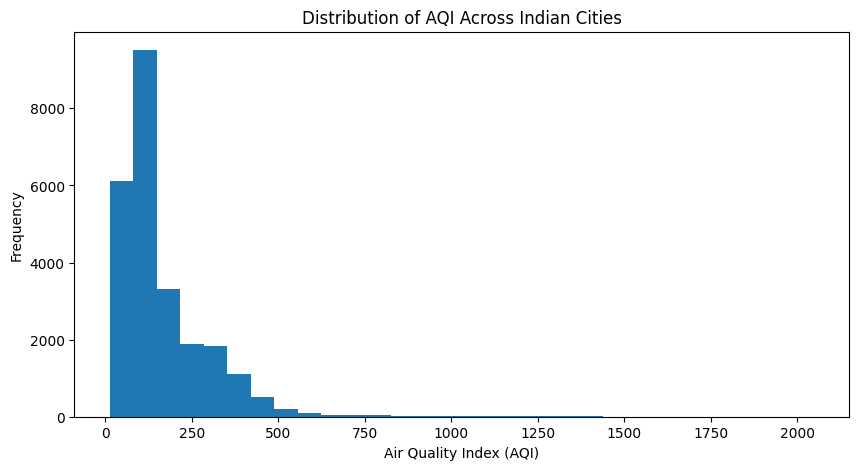

In [94]:
plt.figure(figsize=(10,5))

plt.hist(aqi_values, bins=30)

plt.title("Distribution of AQI Across Indian Cities")
plt.xlabel("Air Quality Index (AQI)")
plt.ylabel("Frequency")

plt.show()

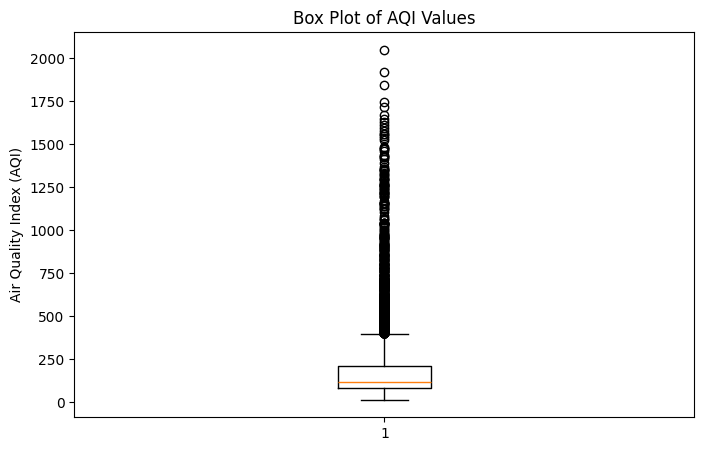

In [95]:
plt.figure(figsize=(8,5))

plt.boxplot(aqi_values)

plt.title("Box Plot of AQI Values")
plt.ylabel("Air Quality Index (AQI)")

plt.show()

mean_aqi > median_aqi thus AQI distribution is right-skewed. Most observations are below the mean. 1358 extreme AQI observations were detected. A small number of highly polluted observations are pulling the average upward.

Histogram: Used to show where AQI values cluster and whether most observations fall into similar pollution levels.

Box Plot: Used to identify extreme AQI values and determine whether a few observations are disproportionately influencing the average AQI.



- The AQI distribution is right-skewed because the mean AQI is higher than the median AQI. This indicates that most observations are concentrated below the average value.
- The box plot identified several AQI outliers above the upper whisker. These extreme pollution observations increase the mean AQI, suggesting that the median AQI may be a more representative measure of typical air quality.

## *TASK 5*

For AQI, a good approach is IQR-based outlier detection because:
- AQI is not normally distributed.
- The histogram and boxplot from Task 4 showed skewness.
- IQR is robust to skewed distributions and extreme values.

In [100]:
aqi_values = aqi_df['AQI'].dropna()
Q1 = aqi_values.quantile(0.25)
Q3 = aqi_values.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f"Q1           : {Q1:.2f}")
print(f"Q3           : {Q3:.2f}")
print(f"IQR          : {IQR:.2f}")
print(f"Lower Bound  : {lower_bound:.2f}")
print(f"Upper Bound  : {upper_bound:.2f}")
outliers = aqi_df[
    (aqi_df['AQI'] < lower_bound) |
    (aqi_df['AQI'] > upper_bound)
]

print(f"\nExtreme AQI Values Found: {len(outliers)}")
print(f"Percentage of Dataset   : {(len(outliers)/len(aqi_df))*100:.2f}%")

print("\nTop Extreme AQI Values:")
print(outliers['AQI'].sort_values(ascending=False).head(10))

Q1           : 81.00
Q3           : 208.00
IQR          : 127.00
Lower Bound  : -109.50
Upper Bound  : 398.50

Extreme AQI Values Found: 1358
Percentage of Dataset   : 4.60%

Top Extreme AQI Values:
1145    2049.0
1136    1917.0
560     1842.0
1048    1747.0
1463    1719.0
1417    1672.0
1420    1646.0
1407    1630.0
1127    1613.0
1746    1595.0
Name: AQI, dtype: float64


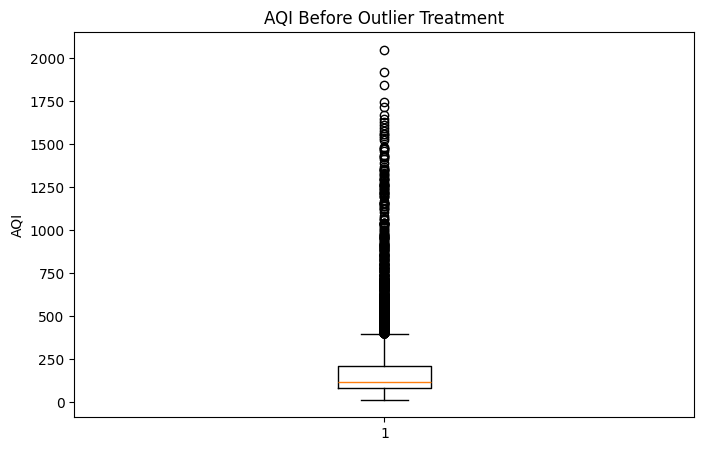

In [101]:
plt.figure(figsize=(8,5))
plt.boxplot(aqi_df['AQI'].dropna())
plt.title("AQI Before Outlier Treatment")
plt.ylabel("AQI")
plt.show()

A better approach is Winsorization. Values above the upper IQR bound are replaced with the upper bound. Values below the lower bound are replaced with the lower bound. Keeps all observations while reducing distortion.

In [103]:
aqi_clean = aqi_df.copy()
affected_before = (
    (aqi_clean['AQI'] < lower_bound) |
    (aqi_clean['AQI'] > upper_bound)
).sum()

aqi_clean['AQI'] = aqi_clean['AQI'].clip(
    lower=lower_bound,
    upper=upper_bound
)
print("TREATMENT APPLIED")
print(f"Values capped: {affected_before}")

TREATMENT APPLIED
Values capped: 1358


In [104]:
remaining_outliers = (
    (aqi_clean['AQI'] < lower_bound) |
    (aqi_clean['AQI'] > upper_bound)
).sum()
print(f"Outliers Before : {affected_before}")
print(f"Outliers After  : {remaining_outliers}")

Outliers Before : 1358
Outliers After  : 0


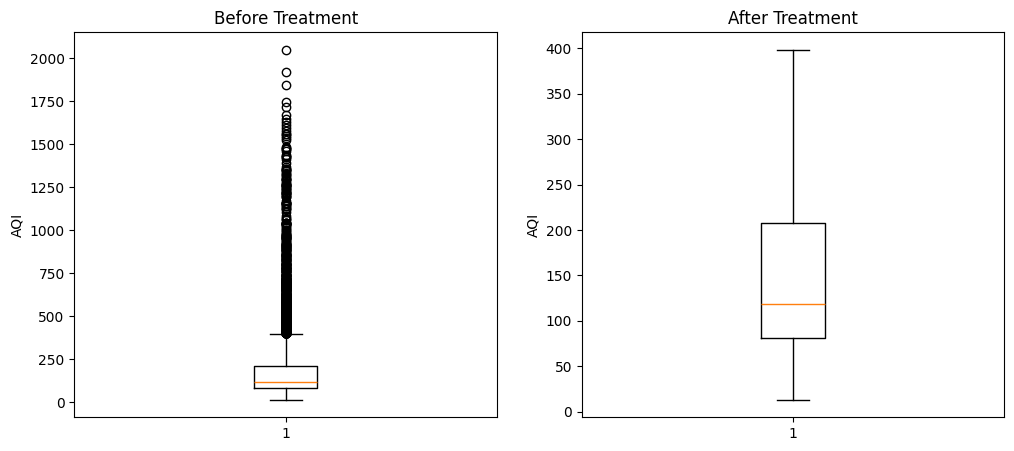

In [105]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.boxplot(aqi_df['AQI'].dropna())
plt.title("Before Treatment")
plt.ylabel("AQI")

plt.subplot(1,2,2)
plt.boxplot(aqi_clean['AQI'].dropna())
plt.title("After Treatment")
plt.ylabel("AQI")

plt.show()

In [106]:
comparison = pd.DataFrame({
    "Before": [
        aqi_df['AQI'].mean(),
        aqi_df['AQI'].median(),
        aqi_df['AQI'].max()
    ],
    "After": [
        aqi_clean['AQI'].mean(),
        aqi_clean['AQI'].median(),
        aqi_clean['AQI'].max()
    ]
}, index=["Mean AQI","Median AQI","Maximum AQI"])

comparison

,Before,After
Mean AQI,166.463581,157.342455
Median AQI,118.000000,118.000000
Maximum AQI,2049.000000,398.500000


The mean AQI decreased after treatment, indicating that a small number of extreme observations were inflating the average AQI. The median AQI changed very little, suggesting that most cities already clustered within a reasonable AQI range and that only a small number of extreme values were responsible for the distortion.